This routine generates **Figure 2 gcam 32 region map** for the paper *"Global Potential of Potable Reuse Across Coupled Climate and Socioeconomic Futures"*. If you have any questions please contact [a.sarfraz@uu.nl](mailto:a.sarfraz@uu.nl).


## 1. Libraries

In [1]:
suppressPackageStartupMessages({
  library(arrow)
  library(dplyr)
  library(ggplot2)
  library(sf)
  library(rmap)
  library(rnaturalearth)
  library(rnaturalearthdata)
  library(gridExtra)
  library(grid)
  library(scales)
  library(viridisLite)
  library(IRdisplay)
})

use_svglite <- tryCatch({
  library(svglite); TRUE
}, error = function(e) {
  message("[INFO] svglite unavailable -- SVG output via base svg()")
  FALSE
})


Warning message:
"package 'arrow' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'sf' was built under R version 4.4.3"
Warning message:
"package 'rnaturalearth' was built under R version 4.4.3"
Warning message:
"package 'gridExtra' was built under R version 4.4.3"
Warning message:
"package 'scales' was built under R version 4.4.3"
Warning message:
"package 'viridisLite' was built under R version 4.4.3"
Warning message:
"package 'IRdisplay' was built under R version 4.4.3"
Warning message:
"package 'svglite' was built under R version 4.4.3"


## 2. Paths

YAML-based path resolution (same as Figure 1). If you do not have
`config/paths.yaml`, comment out the YAML block and uncomment the manual
override at the bottom. Two output subfolders are created up front: one
for PR50, one for PR100.

In [2]:
NB_DIR    <- normalizePath(getwd(), winslash = "/")
REPO_ROOT <- if (basename(NB_DIR) == "notebooks") dirname(NB_DIR) else NB_DIR

cfg <- yaml::read_yaml(file.path(REPO_ROOT, "config", "paths.yaml"))

resolve_path <- function(p) {
  is_abs <- substring(p, 1, 1) == "/" || grepl("^[A-Za-z]:[/\\\\]", p)
  if (is_abs) {
    return(normalizePath(p, winslash = "/", mustWork = FALSE))
  }
  normalizePath(file.path(REPO_ROOT, p), winslash = "/", mustWork = FALSE)
}

PATHS <- list(
  data    = lapply(cfg$data,    resolve_path),
  outputs = lapply(cfg$outputs, resolve_path)
)

PARQUET_DIR <- PATHS$data$regional_reductions_dir


OUT_DIR     <- file.path(PATHS$outputs$figure2,
                         "yearly_maps_individual")

# --- Manual override (uncomment if you do not have config/paths.yaml) ---
# PARQUET_DIR <- r"(C:\Users\Sarfr001\Documents\20260408 Final_codes_figure_sequence\figure 2)"
# OUT_DIR     <- file.path(PARQUET_DIR, "figures", "yearly_maps_individual_cividis")

OUT_PR50  <- file.path(OUT_DIR, "pr50")
OUT_PR100 <- file.path(OUT_DIR, "pr100")
dir.create(OUT_PR50,  recursive = TRUE, showWarnings = FALSE)
dir.create(OUT_PR100, recursive = TRUE, showWarnings = FALSE)

cat("Repo root  :", REPO_ROOT,   "\n")
cat("Parquet dir:", PARQUET_DIR, "\n")
cat("PR50 out   :", OUT_PR50,    "\n")
cat("PR100 out  :", OUT_PR100,   "\n")

Repo root  : C:/Users/Sarfr001/Documents/Global_Potential_Potable_Reuse 
Parquet dir: C:/Users/Sarfr001/Documents/Global_Potential_Potable_Reuse/data/regional_reductions 
PR50 out   : C:/Users/Sarfr001/Documents/Global_Potential_Potable_Reuse/outputs/figure2/yearly_maps_individual/pr50 
PR100 out  : C:/Users/Sarfr001/Documents/Global_Potential_Potable_Reuse/outputs/figure2/yearly_maps_individual/pr100 


## 3. Read parquets and reduce ensemble axis

Each parquet stores one row per (region, year, ensemble member). We
collapse across ensemble members to obtain the median and 25th/75th
percentiles for each (region, year). 

In [3]:
read_reduction <- function(pr_label) {
  path <- file.path(PARQUET_DIR,
                    paste0("regional_reductions_", pr_label, ".parquet"))
  if (!file.exists(path))
    stop("Cannot find: ", path,
         "\nRun the Python regional reduction builder first.")

  arrow::read_parquet(path) |>
    mutate(year = as.integer(year)) |>
    filter(!is.na(pct_reduction)) |>
    group_by(region, year) |>
    summarise(
      median_pct  = median(pct_reduction, na.rm = TRUE),
      q25_pct     = quantile(pct_reduction, 0.25, na.rm = TRUE),
      q75_pct     = quantile(pct_reduction, 0.75, na.rm = TRUE),
      n_scenarios = n(),
      .groups     = "drop"
    ) |>
    mutate(pr_label = pr_label)
}

cat("Reading PR50 parquet...\n")
ens50  <- read_reduction("PR50")
cat("Reading PR100 parquet...\n")
ens100 <- read_reduction("PR100")

all_years <- sort(unique(c(ens50$year, ens100$year)))
cat(sprintf("\nYears   : %s\n", paste(all_years, collapse = ", ")))
cat(sprintf("Regions : %d unique (PR50) | %d unique (PR100)\n\n",
            n_distinct(ens50$region), n_distinct(ens100$region)))

Reading PR50 parquet...
Reading PR100 parquet...

Years   : 2025, 2030, 2035, 2040, 2045, 2050, 2055, 2060, 2065, 2070, 2075, 2080, 2085, 2090, 2095, 2100
Regions : 32 unique (PR50) | 32 unique (PR100)



## 4. Region name crosswalk and verification

In [4]:
# need to fix lables as new region Ukraine added.
name_crosswalk <- c(
  "EU-12"   = "EU_12",
  "EU-15"   = "EU_15",
  "Ukraine" = "Europe_Eastern"
)

apply_crosswalk <- function(df) {
  df |> mutate(subRegion = dplyr::recode(region, !!!name_crosswalk))
}

ens50  <- apply_crosswalk(ens50)
ens100 <- apply_crosswalk(ens100)

rmap_regions  <- sort(rmap::mapGCAMReg32$subRegion)
parquet_after <- sort(unique(c(ens50$subRegion, ens100$subRegion)))
still_grey    <- setdiff(rmap_regions,  parquet_after)
still_lost    <- setdiff(parquet_after, rmap_regions)

## need to verify 
cat("--- Verification ---\n")
if (length(still_grey) == 0) {
  cat("  OK: all rmap polygons have matching parquet data\n")
} else {
  cat("  GREY polygons (no data):", paste(still_grey, collapse = ", "), "\n")
}
if (length(still_lost) == 0) {
  cat("  OK: all parquet regions map to an rmap polygon\n")
} else {
  cat("  LOST regions (no polygon):", paste(still_lost, collapse = ", "), "\n")
}
cat("\n")

--- Verification ---
  OK: all rmap polygons have matching parquet data
  OK: all parquet regions map to an rmap polygon



## 5. Defining color scheme


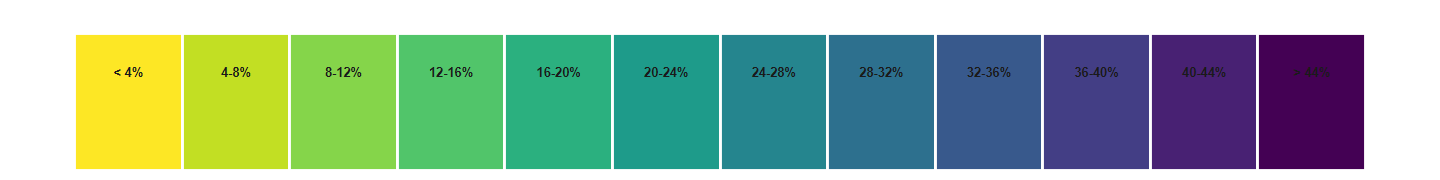

In [5]:

VIRIDIS_OPTION <- "D"          
SCALE_LIMITS   <- c(0, 55)     ## based on previous paraquet 


bin_breaks <- c(-Inf, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, Inf)
bin_labels <- c("< 4%",   "4-8%",   "8-12%",  "12-16%",
                "16-20%", "20-24%", "24-28%", "28-32%",
                "32-36%", "36-40%", "40-44%", "> 44%")


multi_palette <- viridisLite::viridis(n = length(bin_labels),
                                      option    = VIRIDIS_OPTION,
                                      direction = -1)
names(multi_palette) <- bin_labels

bin_values <- function(x) {
  cut(x, breaks = bin_breaks, labels = bin_labels,
      include.lowest = TRUE, right = FALSE)
}


fill_scale_binned <- function(legend_title) {
  ggplot2::scale_fill_manual(
    values   = multi_palette,
    drop     = FALSE,
    na.value = "grey88",
    name     = legend_title,
    guide    = ggplot2::guide_legend(
                 title.position = "top",
                 title.hjust    = 0.5,
                 keywidth       = grid::unit(0.5, "cm"),
                 keyheight      = grid::unit(0.5, "cm"),
                 ncol           = 1)
  )
}

options(repr.plot.width = 12, repr.plot.height = 1.5)
swatch_df <- data.frame(x   = seq_along(multi_palette),
                        bin = factor(bin_labels, levels = bin_labels))
ggplot(swatch_df, aes(x = x, y = 1, fill = bin)) +
  geom_tile(color = "white", linewidth = 0.6) +
  geom_text(aes(label = bin_labels), size = 2.6, fontface = "bold",
            color = "grey10", vjust = -2.4) +
  scale_fill_manual(values = multi_palette) +
  scale_y_continuous(expand = c(0, 0)) +
  coord_cartesian(clip = "off") +
  theme_void() +
  theme(legend.position = "none", plot.margin = margin(20, 6, 6, 6)) 

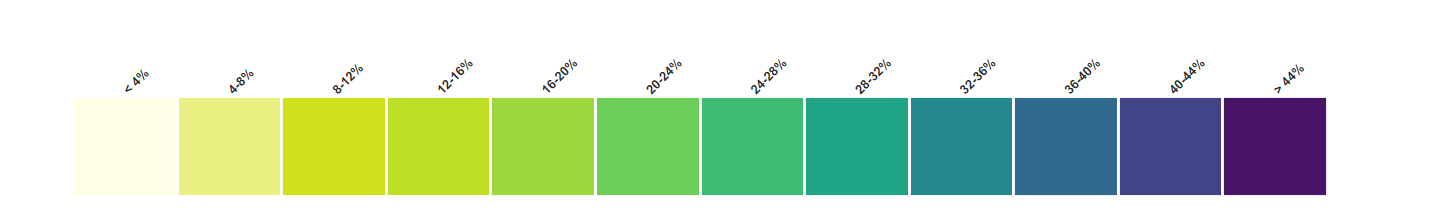

In [7]:
VIRIDIS_OPTION <- "D"
SCALE_LIMITS   <- c(0, 55)

bin_breaks <- c(-Inf, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, Inf)
bin_labels <- c("< 4%","4-8%","8-12%","12-16%","16-20%","20-24%",
                "24-28%","28-32%","32-36%","36-40%","40-44%","> 44%")
n_bins <- length(bin_labels)

n_light      <- 2          # leading bins held very light
light_anchor <- "#FFFFE6"  # near-white cream for the lowest bin
vir_end      <- 0.93       # <1 delays pure yellow ("start yellow later")
vir_begin    <- 0.05       # drop the near-black extreme of option D
gamma_top    <- 1.6        # >1 spreads the dark/high-value bins apart

n_color <- n_bins - n_light

ref <- viridisLite::viridis(256, option = VIRIDIS_OPTION, direction = -1,
                            begin = vir_begin, end = vir_end)


pos  <- seq(0, 1, length.out = n_color)^gamma_top
core <- ref[round(1 + pos * 255)]

light_ramp <- grDevices::colorRampPalette(c(light_anchor, core[1]))(n_light + 1)[seq_len(n_light)]

multi_palette        <- c(light_ramp, core)
names(multi_palette) <- bin_labels

bin_values <- function(x) cut(x, breaks = bin_breaks, labels = bin_labels,
                              include.lowest = TRUE, right = FALSE)

fill_scale_binned <- function(legend_title) {
  ggplot2::scale_fill_manual(
    values = multi_palette, drop = FALSE, na.value = "grey88",
    name = legend_title,
    guide = ggplot2::guide_legend(title.position = "top", title.hjust = 0.5,
              keywidth = grid::unit(0.5, "cm"),
              keyheight = grid::unit(0.5, "cm"), ncol = 1))
}

options(repr.plot.width = 12, repr.plot.height = 1.8)
swatch_df <- data.frame(x = seq_along(multi_palette),
                        bin = factor(bin_labels, levels = bin_labels))
ggplot(swatch_df, aes(x, 1, fill = bin)) +
  geom_tile(color = "white", linewidth = 0.6) +
  geom_text(aes(label = bin_labels), size = 2.6, fontface = "bold",
            color = "grey15", angle = 45, hjust = 0, nudge_y = 0.55) +
  scale_fill_manual(values = multi_palette) +
  scale_y_continuous(expand = c(0, 0), limits = c(0.4, 2)) +
  coord_cartesian(clip = "off") +
  theme_void() +
  theme(legend.position = "none", plot.margin = margin(28, 30, 6, 6))

## 6. Gap countries

In [8]:
## few fixes required for mapping


gap_lookup <- data.frame(
  nat_earth_name = c("Belarus",       "Moldova",       "S. Sudan"),
  gcam_subRegion = c("Europe_Non_EU", "Europe_Non_EU", "Africa_Eastern"),
  stringsAsFactors = FALSE
)

world_ne <- rnaturalearth::ne_countries(
  scale = "medium", returnclass = "sf"
) |>
  select(name, geometry) |>
  st_transform(crs = st_crs(rmap::mapGCAMReg32))

found     <- gap_lookup$nat_earth_name[ gap_lookup$nat_earth_name %in% world_ne$name]
not_found <- gap_lookup$nat_earth_name[!gap_lookup$nat_earth_name %in% world_ne$name]
cat("Gap country overlays found    :", paste(found, collapse = ", "), "\n")
if (length(not_found) > 0) {
  cat("Gap country overlays NOT found:", paste(not_found, collapse = ", "), "\n")
}
cat("\n")

gap_geom_sf <- world_ne |>
  filter(name %in% gap_lookup$nat_earth_name) |>
  left_join(gap_lookup, by = c("name" = "nat_earth_name")) |>
  rename(subRegion = gcam_subRegion) |>
  select(subRegion, geometry)

Gap country overlays found    : Belarus, Moldova, S. Sudan 



## 7. Per-region stats footer

In [9]:
# Build a fixed-width, multi-column statistics table for one year.

format_region_stats <- function(ens_yr, n_cols = 4) {

  if (nrow(ens_yr) == 0) return("(no data)")

  ens_sorted <- ens_yr |> dplyr::arrange(region)
  region_chr <- as.character(ens_sorted$region)

  name_w  <- max(nchar(region_chr))
  entries <- sprintf("%-*s %5.1f%%  (%4.1f-%4.1f)",
                     name_w, region_chr,
                     ens_sorted$median_pct,
                     ens_sorted$q25_pct,
                     ens_sorted$q75_pct)


  n      <- length(entries)
  n_rows <- ceiling(n / n_cols)
  if (n < n_rows * n_cols) {
    pad <- strrep(" ", nchar(entries[1]))
    entries <- c(entries, rep(pad, n_rows * n_cols - n))
  }
  mat  <- matrix(entries, nrow = n_rows, ncol = n_cols, byrow = TRUE)
  rows <- apply(mat, 1, paste, collapse = "    ")

  paste(rows, collapse = "\n")
}

build_stats_block <- function(ens_yr, n_cols = 4) {
  hdr  <- "Per-region ensemble statistics: median %  (Q1-Q3 IQR)"
  body <- format_region_stats(ens_yr, n_cols)
  paste(hdr, strrep("-", nchar(hdr)), body, sep = "\n")
}

## 8. Single-panel builder


In [10]:
build_panel <- function (ens_yr, title_text, palette = NULL, legend_title)
{
    map_sf <- left_join(select(rmap::mapGCAMReg32, subRegion,
        geometry), select(ens_yr, subRegion, median_pct), by = "subRegion")
    gap_sf <- left_join(gap_geom_sf, select(ens_yr, subRegion,
        median_pct), by = "subRegion")

    # Cut the continuous value into the 12 canonical ordered bins.
    map_sf$fill_bin <- bin_values(map_sf$median_pct)
    gap_sf$fill_bin <- bin_values(gap_sf$median_pct)

    n_matched <- sum(!is.na(map_sf$median_pct))
    cat(sprintf("    %-65s  %d/%d matched\n", substr(title_text,
        1, 65), n_matched, nrow(map_sf)))

    ggplot() +
        geom_sf(data = rmap::mapCountries, fill = "grey96",
            color = "grey70", linewidth = 0.12) +
        geom_sf(data = map_sf, aes(fill = fill_bin),
            color = "grey25", linewidth = 0.3) +
        geom_sf(data = gap_sf, aes(fill = fill_bin),
            color = "grey25", linewidth = 0.3) +
        scale_fill_manual(values = multi_palette, drop = FALSE,
            na.value = "grey88", name = legend_title,
            guide = guide_legend(title.position = "top",
                title.hjust = 0.5,
                keywidth  = unit(0.5, "cm"),
                keyheight = unit(0.5, "cm"),
                ncol = 1)) +
        coord_sf(xlim = c(-180, 180), ylim = c(-58, 85), expand = FALSE) +
        labs(title = title_text) +
        theme_void() +
        theme(plot.title = element_text(size = 13, face = "bold",
                hjust = 0.03, margin = margin(t = 4, b = 2)),
            plot.background  = element_rect(fill = "white", color = NA),
            panel.background = element_rect(fill = "white", color = NA),
            panel.border     = element_blank(),
            plot.margin      = margin(4, 8, 4, 8),
            legend.position  = "right",
            legend.title     = element_text(size = 10, face = "bold"),
            legend.text      = element_text(size = 9),
            legend.background = element_rect(fill = "white", color = NA))
}



## 9. SVG save helper

In [11]:
## feel free to comment - saving svgs for presentations
save_svg <- function(plot_obj, path, w, h) {
  if (use_svglite) {
    ggsave(path, plot = plot_obj, width = w, height = h,
           bg = "white", device = svglite::svglite)
  } else {
    svg(filename = path, width = w, height = h, bg = "white")
    grid.draw(plot_obj)
    dev.off()
  }
}

## 10. Composing one full figure



In [12]:
render_one_figure <- function(ens_yr, year, scenario_label,
                              palette = NULL, out_dir,
                              fig_w = 18, fig_h = 12) {

  # Map panel.
  panel <- build_panel(
    ens_yr       = ens_yr,
    title_text   = sprintf(
      "%s  -  Ensemble Median Municipal Withdrawal Reduction  (%d)",
      scenario_label, year),
    legend_title = "% Reduction\nfrom PR0"
  )

  # Header title with scenario and year.
  header_grob <- textGrob(
    sprintf(paste0(
      "%s  |  Regional Ensemble Median Municipal Water Withdrawal",
      " Reduction vs. No-Reuse Baseline  |  Year %d\n"),
      scenario_label, year),
    gp    = gpar(fontsize = 12, fontface = "bold"),
    hjust = 0.5, x = 0.5
  )

  stats_grob <- textGrob(
    build_stats_block(ens_yr, n_cols = 4),
    just = c("left", "top"),
    x    = unit(8, "mm"),
    y    = unit(1, "npc") - unit(2, "mm"),
    gp   = gpar(fontsize = 8, fontfamily = "mono", lineheight = 1.25)
  )

  combined <- arrangeGrob(
    header_grob, panel, stats_grob,
    ncol    = 1,
    heights = c(0.55, 4, 1.6)
  )

  out_png <- file.path(out_dir,
                       sprintf("%s_%d.png", tolower(scenario_label), year))

  ## feel free to comment out   
  out_svg <- file.path(out_dir,
                       sprintf("%s_%d.svg", tolower(scenario_label), year))

  ggsave(out_png, plot = combined,
         width = fig_w, height = fig_h, dpi = 300, bg = "white")
  save_svg(combined, out_svg, w = fig_w, h = fig_h)

  cat(sprintf("  -> %s\n  -> %s\n", basename(out_png), basename(out_svg)))

  invisible(combined)
}

## 11. Per-year loop

For each modelled year, render and save one PR50 figure to
`<OUT_DIR>/pr50/` and one PR100 figure to `<OUT_DIR>/pr100/`. Both go
out as PNG (300 dpi) and SVG.

In [13]:
cat("Generating individual figures...\n\n")

for (yr in all_years) {

  cat(sprintf("Year %d:\n", yr))

  s50  <- ens50  |> filter(year == yr)
  s100 <- ens100 |> filter(year == yr)

  if (nrow(s50) == 0 && nrow(s100) == 0) {
    cat("  [skip] no data\n\n"); next
  }

  if (nrow(s50) > 0) {
    render_one_figure(ens_yr = s50,  year = yr,
                      scenario_label = "PR50",
                      palette = multi_palette, out_dir = OUT_PR50)
  }

  if (nrow(s100) > 0) {
    render_one_figure(ens_yr = s100, year = yr,
                      scenario_label = "PR100",
                      palette = multi_palette, out_dir = OUT_PR100)
  }

  cat("\n")
}

cat(rep("=", 65), "\n")
cat(sprintf("DONE -- %d years x 2 scenarios x 2 file formats\n",
            length(all_years)))
cat(sprintf("PR50  output: %s\n", OUT_PR50))
cat(sprintf("PR100 output: %s\n", OUT_PR100))
cat(rep("=", 65), "\n")

Generating individual figures...

Year 2025:
    PR50  -  Ensemble Median Municipal Withdrawal Reduction  (2025)    32/32 matched
  -> pr50_2025.png
  -> pr50_2025.svg
    PR100  -  Ensemble Median Municipal Withdrawal Reduction  (2025)   32/32 matched
  -> pr100_2025.png
  -> pr100_2025.svg

Year 2030:
    PR50  -  Ensemble Median Municipal Withdrawal Reduction  (2030)    32/32 matched
  -> pr50_2030.png
  -> pr50_2030.svg
    PR100  -  Ensemble Median Municipal Withdrawal Reduction  (2030)   32/32 matched
  -> pr100_2030.png
  -> pr100_2030.svg

Year 2035:
    PR50  -  Ensemble Median Municipal Withdrawal Reduction  (2035)    32/32 matched
  -> pr50_2035.png
  -> pr50_2035.svg
    PR100  -  Ensemble Median Municipal Withdrawal Reduction  (2035)   32/32 matched
  -> pr100_2035.png
  -> pr100_2035.svg

Year 2040:
    PR50  -  Ensemble Median Municipal Withdrawal Reduction  (2040)    32/32 matched
  -> pr50_2040.png
  -> pr50_2040.svg
    PR100  -  Ensemble Median Municipal Withdrawal R

## recheckign mapping of regions

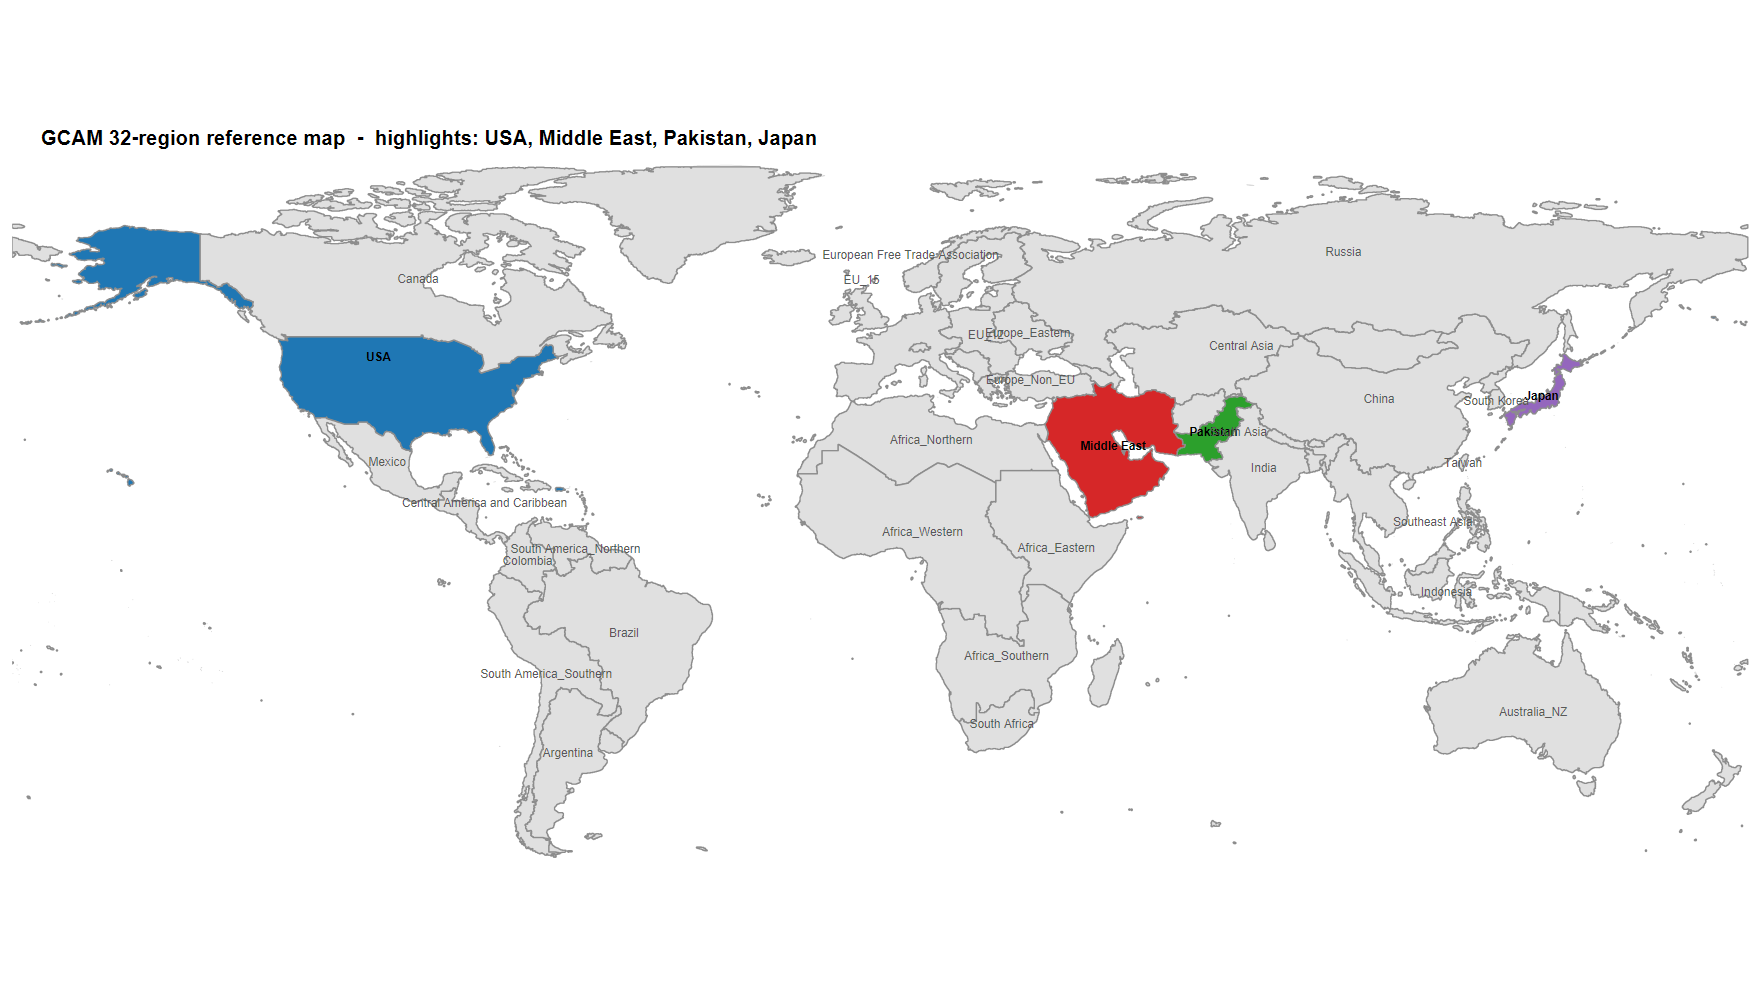

In [14]:
# Regions to highlight, with the colors used to fill them. Names must
# match the rmap subRegion labels exactly.
highlight <- c(
  "USA"         = "#1f77b4",   # blue
  "Middle East" = "#d62728",   # brick red
  "Pakistan"    = "#2ca02c",   # green
  "Japan"       = "#9467bd"    # purple
)


map_sf <- rmap::mapGCAMReg32 |>
  dplyr::select(subRegion, geometry) |>
  dplyr::mutate(
    fill_col = ifelse(subRegion %in% names(highlight),
                      highlight[as.character(subRegion)],
                      "grey88")
  )

suppressWarnings({
  ctr       <- sf::st_centroid(map_sf)
  map_sf$cx <- sf::st_coordinates(ctr)[, 1]
  map_sf$cy <- sf::st_coordinates(ctr)[, 2]
})

# Highlighted regions get bold black labels; the rest get a lighter grey
# label so they remain readable but visually recede.
map_sf$lab_face  <- ifelse(map_sf$subRegion %in% names(highlight),
                           "bold", "plain")
map_sf$lab_color <- ifelse(map_sf$subRegion %in% names(highlight),
                           "black", "grey35")

options(repr.plot.width = 16, repr.plot.height = 9, repr.plot.res = 110)

ggplot() +
  # Country basemap underneath.
  geom_sf(data = rmap::mapCountries,
          fill = "white", color = "grey80", linewidth = 0.12) +
  # GCAM polygons, colored by the per-row fill_col.
  geom_sf(data = map_sf, aes(fill = fill_col),
          color = "grey55", linewidth = 0.3) +
  scale_fill_identity() +
  geom_text(data = map_sf,
            aes(x = cx, y = cy, label = subRegion,
                fontface = lab_face, color = lab_color),
            size = 2.6) +
  scale_color_identity() +
  coord_sf(xlim = c(-180, 180), ylim = c(-58, 85), expand = FALSE) +
  labs(title = "GCAM 32-region reference map  -  highlights: USA, Middle East, Pakistan, Japan") +
  theme_void() +
  theme(
    plot.title       = element_text(size = 13, face = "bold", hjust = 0.03,
                                    margin = margin(t = 4, b = 6)),
    plot.background  = element_rect(fill = "white", color = NA),
    panel.background = element_rect(fill = "white", color = NA),
    panel.border     = element_blank(),
    plot.margin      = margin(6, 8, 6, 8)
  )

# ggsave(file.path(OUT_DIR, "reference_map_highlights.png"),
#        width = 16, height = 9, dpi = 300, bg = "white")
# ggsave(file.path(OUT_DIR, "reference_map_highlights.svg"),
#        width = 16, height = 9, bg = "white",
#        device = if (use_svglite) svglite::svglite else NULL)